1. DATASET ORIGINAL SIMULADO (Contagens Brutas)
  Sample_ID    Group  Escherichia_coli  Lactobacillus_spp  \
0        S1  Healthy                11                 83   
1        S2  Healthy                24                 62   
2        S3  Healthy                19                 81   
3        S4  Healthy                15                 61   
4        S5  Healthy                12                 83   

   Staphylococcus_aureus  Bacillus_subtilis  Pseudomonas_aeruginosa  
0                     10                 47                       4  
1                      6                 35                       9  
2                     13                 34                       3  
3                     12                 49                       5  
4                      9                 49                       3  

... Dataset salvo em 'data/microbiome_dataset.csv' ...

2. DADOS NORMALIZADOS (Abundância Relativa %)
  Sample_ID    Group  Escherichia_coli  Lactobacillus_spp  \
0

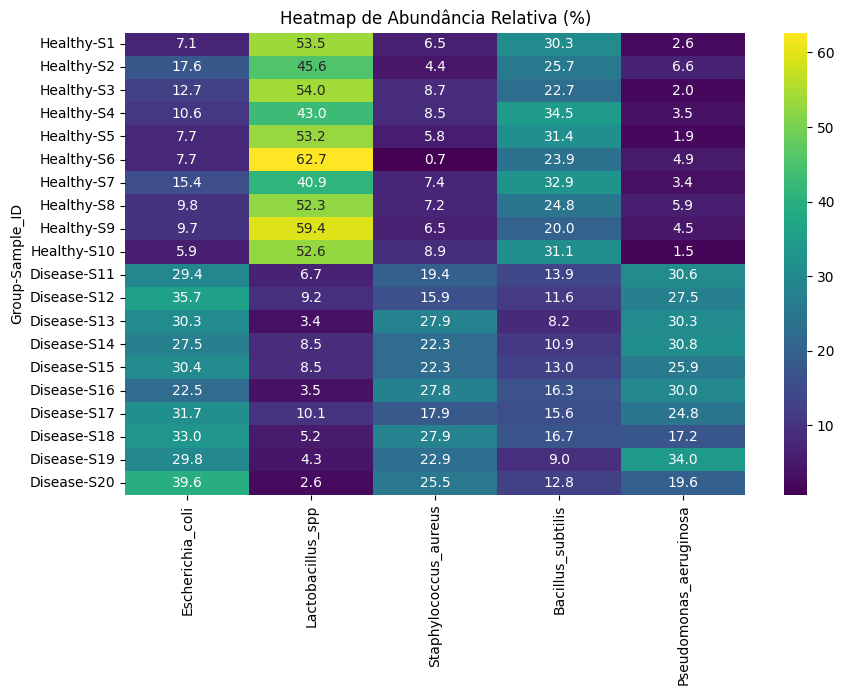

4. COORDENADAS GERADAS PELO PCA (Primeiras Amostras)
        PC1       PC2    Group
0  2.437394  0.164546  Healthy
1  1.568975 -0.188085  Healthy
2  1.736874 -0.301162  Healthy
3  2.169872  0.821083  Healthy
4  2.520810  0.248647  Healthy

Variância explicada por componente: PC1 = 89.8%, PC2 = 5.0%



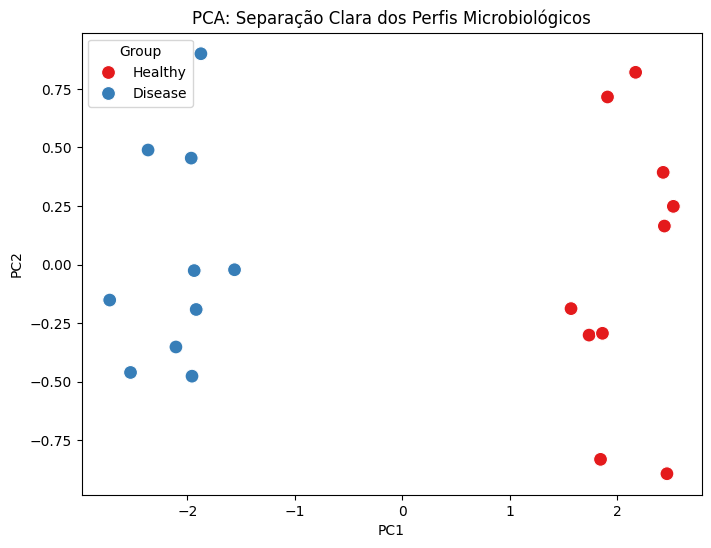

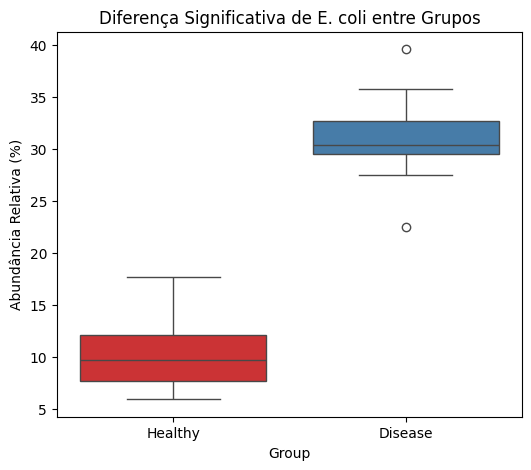

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Garantir que as pastas de destino existam
os.makedirs('data', exist_ok=True)
os.makedirs('images', exist_ok=True)

# ==========================================
# CRIAÇÃO DO DATASET (DIFERENÇAS BIOLÓGICAS)
# ==========================================
np.random.seed(42)

healthy_data = {
    'Sample_ID': [f'S{i}' for i in range(1, 11)],
    'Group': ['Healthy'] * 10,
    'Escherichia_coli': np.random.randint(5, 25, 10),
    'Lactobacillus_spp': np.random.randint(60, 95, 10),
    'Staphylococcus_aureus': np.random.randint(1, 15, 10),
    'Bacillus_subtilis': np.random.randint(20, 50, 10),
    'Pseudomonas_aeruginosa': np.random.randint(1, 10, 10)
}

disease_data = {
    'Sample_ID': [f'S{i}' for i in range(11, 21)],
    'Group': ['Disease'] * 10,
    'Escherichia_coli': np.random.randint(50, 95, 10),
    'Lactobacillus_spp': np.random.randint(5, 30, 10),
    'Staphylococcus_aureus': np.random.randint(30, 70, 10),
    'Bacillus_subtilis': np.random.randint(10, 40, 10),
    'Pseudomonas_aeruginosa': np.random.randint(40, 80, 10)
}

df = pd.concat([pd.DataFrame(healthy_data), pd.DataFrame(disease_data)], ignore_index=True)
df.to_csv('data/microbiome_dataset.csv', index=False)

print("="*50)
print("1. DATASET ORIGINAL SIMULADO (Contagens Brutas)")
print("="*50)
print(df.head(5)) # Mostra as primeiras linhas do dataset original
print("\n... Dataset salvo em 'data/microbiome_dataset.csv' ...\n")

# ==========================================
# NORMALIZAÇÃO: ABUNDÂNCIA RELATIVA (%)
# ==========================================
bacterias = ['Escherichia_coli', 'Lactobacillus_spp', 'Staphylococcus_aureus', 'Bacillus_subtilis', 'Pseudomonas_aeruginosa']
df_relativo = df.copy()
df_relativo[bacterias] = df[bacterias].div(df[bacterias].sum(axis=1), axis=0) * 100

print("="*50)
print("2. DADOS NORMALIZADOS (Abundância Relativa %)")
print("="*50)
print(df_relativo.head(5)) # Mostra os dados após a conversão para porcentagem
print("\n")

# ==========================================
# MÉDIA BACTERIANA POR GRUPO
# ==========================================
medias = df_relativo.groupby('Group')[bacterias].mean()
print("="*50)
print("3. ABUNDÂNCIA MÉDIA POR GRUPO EXPERIMENTAL (%)")
print("="*50)
print(medias) # Exibe a tabela comparativa de médias textuais
print("\n")

# ==========================================
# VISUALIZAÇÕES: HEATMAP
# ==========================================
dados_heatmap = df_relativo.set_index(['Group', 'Sample_ID'])
plt.figure(figsize=(10,6))
sns.heatmap(dados_heatmap, cmap='viridis', annot=True, fmt=".1f")
plt.title('Heatmap de Abundância Relativa (%)')
plt.savefig('images/heatmap_microbiome.png', bbox_inches='tight')
plt.show()

# ==========================================
# PCA E EXPUSH DOS COMPONENTES
# ==========================================
X = df_relativo[bacterias]
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Group'] = df_relativo['Group']

print("="*50)
print("4. COORDENADAS GERADAS PELO PCA (Primeiras Amostras)")
print("="*50)
print(pca_df.head(5)) # Mostra os valores numéricos de PC1 e PC2 calculados
print(f"\nVariância explicada por componente: PC1 = {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 = {pca.explained_variance_ratio_[1]*100:.1f}%\n")

# Gráfico PCA
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Group', palette='Set1', s=100)
plt.title('PCA: Separação Clara dos Perfis Microbiológicos')
plt.savefig('images/pca_microbiome.png', bbox_inches='tight')
plt.show()

# Gráfico Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(data=df_relativo, x='Group', y='Escherichia_coli', hue='Group', palette='Set1', legend=False)
plt.title('Diferença Significativa de E. coli entre Grupos')
plt.ylabel('Abundância Relativa (%)')
plt.savefig('images/boxplot_ecoli.png', bbox_inches='tight')
plt.show()